# Instructions on using this Calculator

## Introduction

This Jupyter Notebook can be used to calculate the accuracy of your Model Output. It works as follows. Please ensure the following are loaded into your environment before running this notebook: 

1) All 5 clipped CDL tif images, named 2019_cdl_clipped.tif, 2020_cdl_clipped.tif, 2021_cdl_clipped.tif, 2022_cdl_clipped.tif and 2023_cdl_clipped.tif
2) The vector image output from your model, named model_output.tif

## Step 1 - CDL Image Labeling

This section of code will process each CDL filed into 2 data frames. The first daraframe will assign crop labels and field labels with no noise reduction. The second dataframe will perform the same action, except it will apply a median filter. A median filter is a type of non-linear filter used to remove noise from an image or data. It replaces each pixel's value with the median of the pixel values in its neighborhood (3x3 square block in this case).

Note - You only need to run this step one time in order to prep your CDL dataframes for step 2.

In [3]:
import rasterio
import numpy as np
import pandas as pd
from rasterio.windows import Window
import matplotlib.pyplot as plt
import cv2
from skimage.measure import label
from PIL import Image
from scipy.ndimage import median_filter

In [4]:
# Load Reference CDL Images
reference_tif_2019 = "2019_cdl_clipped.tif"
reference_tif_2020 = "2020_cdl_clipped.tif"
reference_tif_2021 = "2021_cdl_clipped.tif"
reference_tif_2022 = "2022_cdl_clipped.tif"
reference_tif_2023 = "2023_cdl_clipped.tif"

In [5]:
#Saves file references in list
tif_files = [
    reference_tif_2019,
    reference_tif_2020,
    reference_tif_2021,
    reference_tif_2022,
    reference_tif_2023
]

In [9]:
#NEED TO UPDATE SO THAT ALL GRAYSCALE VALUES ARE INCLUDED
# Define crop mapping (grayscale values to crop labels)
CROP_TYPE_MAP = {
    0: "Corn", 
    4: "Sorghum", 
    5: "Soybeans", 
    6: "Sunflower", 
    12: "Sweet Corn", 
    13: "Pop or Orn Corn", 
    14: "Mint", 
    21: "Barley", 
    23: "Spring Wheat", 
    24: "Winter Wheat", 
    26: "Dbl Crop WinWht/Soybeans", 
    27: "Rye",
    28: "Oats",
    29: "Millet",
    30: "Speltz",
    31: "Canola",
    36: "Alfalfa",
    37: "Other Hay/Non Alfalfa",
    39: "Buckwheat",
    41: "Sugarbeets",
    42: "Dry Beans",
    43: "Potatoes",
    44: "Other Crops",
    47: "Misc Vegs & Fruits",
    48: "Watermelons",
    49: "Onions",
    50: "Cucumbers",
    53: "Peas",
    54: "Tomatoes",
    58: "Clover/Wildflowers",
    59: "Sod/Grass Seed",
    60: "Switchgrass",
    61: "Fallow/Idle Cropland",
    66: "Cherries",
    67: "Peaches",
    68: "Apples",
    69: "Grapes",
    70: "Christmas Trees",
    71: "Other Tree Crops",
    77: "Pears",
    92: "Aquaculture",
    111: "Open Water",
    121: "Developed/Open Space",
    122: "Developed/Low Intensity",
    123: "Developed/Med Intensity ",
    124: "Developed/High Intensity",
    131: "Barren",
    141: "Deciduous Forest",
    142: "Evergreen Forest",
    143: "Mixed Forest",
    152: "Shrubland",
    176: "Grassland/Pasture",
    190: "Woody Wetlands",
    195: "Herbaceous Wetlands",
    205: "Triticale",
    206: "Carrots",
    207: "Asparagus",
    209: "Cantaloupes",
    216: "Peppers",
    220: "Plums",
    222: "Squash",
    225: "Dbl Crop WinWht/Corn",
    228: "Dbl Crop Triticale/Corn",
    229: "Pumpkins",
    236: "Dbl Crop WinWht/Sorghum",
    240: "Dbl Crop Soybeans/Oats",
    242: "Blueberries",
    243: "Cabbage",
    245: "Celery",
    247: "Turnips"
}

In [12]:
#Uses the CROP_TYPE_MAP to apply crop labels to each pixel based on their grayscale value

def label_crops (reference_tif):
# Open the TIFF image
    with rasterio.open(reference_tif) as src:
        # Read the image data (first band)
        band = src.read(1)  # Read the first band (single-band image)

        # Get the image dimensions
        height, width = band.shape

    # Generate x and y coordinate arrays
    x_coords, y_coords = np.meshgrid(np.arange(width), np.arange(height))

    # Flatten the arrays and create a DataFrame
    df = pd.DataFrame({
        'x': x_coords.flatten(),
        'y': y_coords.flatten(),
        'grayscale_value': band.flatten()
    })
    
    # Function to map grayscale values to crop types
    def map_crop(grayscale_value):
        return CROP_TYPE_MAP.get(grayscale_value, "Unknown")  # Default to "Unknown" if not found

    # Apply the mapping function to create the 'crop_type' column
    df['crop_type'] = df['grayscale_value'].apply(map_crop)

    # Display the first few rows of the DataFrame
    return df

In [13]:
#Function to group pixels together based on color and assign field labels (no median filter). Adds field_id column onto existing dataframe
def label_fields_no_filter(df: pd.DataFrame, reference_tif):
    # Open the TIFF file
    with rasterio.open(reference_tif) as ref_src:
        ref_image = ref_src.read(1)  # Read as grayscale
        ref_image = ref_image.astype(np.uint8)

    #Apply a median filter to remove noise & prevent small pixel errors (removing this line keeps noise)
    #ref_image = median_filter(ref_image, size=3)  

    height, width = ref_image.shape
    
    # Get unique grayscale values (excluding 0 as background)
    unique_values = np.unique(ref_image)
    filtered_values = unique_values[unique_values > 0]  

    # Prepare empty field ID map
    field_labels = np.zeros_like(ref_image, dtype=np.int32)

    # Initialize field ID counter
    field_counter = 1  

    # Add field_id column to df
    df["field_id"] = 0  

    # Process each grayscale value separately
    for value in filtered_values:
        mask = (ref_image == value)  # Boolean mask for this grayscale value

        # Ensure we only label within this grayscale category
        labeled_regions = label(mask)  

        # Offset labels to ensure uniqueness across grayscale categories
        labeled_regions[labeled_regions > 0] += field_counter  

        # Ensure labels are only updated within this mask
        field_labels[mask] = labeled_regions[mask]

        # Get row and column indices where mask is True
        rows, cols = np.where(mask)

        # Extract the correct field IDs
        field_ids = labeled_regions[rows, cols]

        # Create a DataFrame mapping (y, x) to field_id
        field_update_df = pd.DataFrame({
            "y": rows,
            "x": cols,
            "field_id": field_ids
        })

        # Merge efficiently without overwriting fields incorrectly
        df = df.merge(field_update_df, on=["y", "x"], how="left", suffixes=("", "_new"))
        df["field_id"] = df["field_id_new"].fillna(df["field_id"]).astype(int)
        df.drop(columns=["field_id_new"], inplace=True)

        # Ensure next field ID does not overlap
        field_counter = field_labels.max() + 1  

    return df, field_labels

In [14]:
#Function to group pixels together based on color and assign field labels (with median filter). Adds field_id column onto existing dataframe
def label_fields_with_filter(df: pd.DataFrame, reference_tif):
    # Open the TIFF file
    with rasterio.open(reference_tif) as ref_src:
        ref_image = ref_src.read(1)  # Read as grayscale
        ref_image = ref_image.astype(np.uint8)

    #Apply a median filter to remove noise & prevent small pixel errors (removing this line keeps noise)
    ref_image = median_filter(ref_image, size=3)  

    height, width = ref_image.shape
    
    # Get unique grayscale values (excluding 0 as background)
    unique_values = np.unique(ref_image)
    filtered_values = unique_values[unique_values > 0]  

    # Prepare empty field ID map
    field_labels = np.zeros_like(ref_image, dtype=np.int32)

    # Initialize field ID counter
    field_counter = 1  

    # Add field_id column to df
    df["field_id"] = 0  

    # Process each grayscale value separately
    for value in filtered_values:
        mask = (ref_image == value)  # Boolean mask for this grayscale value

        # Ensure we only label within this grayscale category
        labeled_regions = label(mask)  

        # Offset labels to ensure uniqueness across grayscale categories
        labeled_regions[labeled_regions > 0] += field_counter  

        # Ensure labels are only updated within this mask
        field_labels[mask] = labeled_regions[mask]

        # Get row and column indices where mask is True
        rows, cols = np.where(mask)

        # Extract the correct field IDs
        field_ids = labeled_regions[rows, cols]

        # Create a DataFrame mapping (y, x) to field_id
        field_update_df = pd.DataFrame({
            "y": rows,
            "x": cols,
            "field_id": field_ids
        })

        # Merge efficiently without overwriting fields incorrectly
        df = df.merge(field_update_df, on=["y", "x"], how="left", suffixes=("", "_new"))
        df["field_id"] = df["field_id_new"].fillna(df["field_id"]).astype(int)
        df.drop(columns=["field_id_new"], inplace=True)

        # Ensure next field ID does not overlap
        field_counter = field_labels.max() + 1  

    return df, field_labels

In [15]:
#Process CDL tifs no filter
field_label_df_2019_no_filter, field_labels_2019_no_filter = label_fields_no_filter((label_crops(reference_tif_2019)), reference_tif_2019)
field_label_df_2020_no_filter, field_labels_2020_no_filter = label_fields_no_filter((label_crops(reference_tif_2020)), reference_tif_2020)
field_label_df_2021_no_filter, field_labels_2021_no_filter = label_fields_no_filter((label_crops(reference_tif_2021)), reference_tif_2021)
field_label_df_2022_no_filter, field_labels_2022_no_filter = label_fields_no_filter((label_crops(reference_tif_2022)), reference_tif_2022)
field_label_df_2023_no_filter, field_labels_2023_no_filter = label_fields_no_filter((label_crops(reference_tif_2023)), reference_tif_2023)

#Process CDL tifs with filter
field_label_df_2019_with_filter, field_labels_2019_with_filter = label_fields_with_filter((label_crops(reference_tif_2019)), reference_tif_2019)
field_label_df_2020_with_filter, field_labels_2020_with_filter = label_fields_with_filter((label_crops(reference_tif_2020)), reference_tif_2020)
field_label_df_2021_with_filter, field_labels_2021_with_filter = label_fields_with_filter((label_crops(reference_tif_2021)), reference_tif_2021)
field_label_df_2022_with_filter, field_labels_2022_with_filter = label_fields_with_filter((label_crops(reference_tif_2022)), reference_tif_2022)
field_label_df_2023_with_filter, field_labels_2023_with_filter = label_fields_with_filter((label_crops(reference_tif_2023)), reference_tif_2023)

In [ ]:
######## EVERYTHING AFTER THIS POINT IN STEP 1 IS USED TO CREATE VISUALIZATIONS FOR THE REPORT. YOU CAN SKIP TO STEP 2 ######## 

In [23]:
#Code look at how many differet crop labels exist in 1 field
print("Unique field IDs assigned:", np.unique(field_labels_2019_with_filter))
print(field_label_df_2019_with_filter.groupby("field_id")["crop_type"].nunique().sort_values(ascending=False))

Unique field IDs assigned: [    0     2     3 ... 71267 71268 71269]
field_id
68258    25
62915    22
62001    21
57509    21
59144    21
         ..
21878     1
21880     1
21881     1
47899     1
35639     1
Name: crop_type, Length: 71231, dtype: int64


In [30]:
#Print number of unique fields for a year
num_unique_fields = field_label_df_2019_with_filter["field_id"].nunique()
print(f"Number of unique fields: {num_unique_fields}")

Number of unique fields: 71231


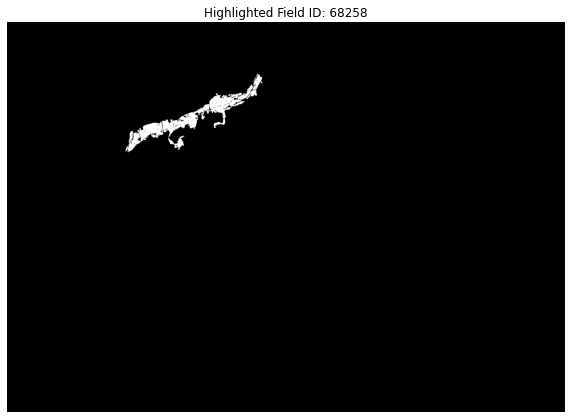

In [28]:
# Show visualization of a specific field

# Select the field ID you want to highlight
target_field_id = 68258  # Change this to the field ID you want to highlight

# Create a binary mask: White (255) for the target field, Black (0) for others
highlight_mask = np.zeros_like(field_labels_2019_with_filter, dtype=np.uint8)
highlight_mask[field_labels_2019_with_filter == target_field_id] = 255  # Set the target field to white

# Display the mask
plt.figure(figsize=(10, 10))
plt.imshow(highlight_mask, cmap='gray')  # Black & White representation
plt.title(f"Highlighted Field ID: {target_field_id}")
plt.axis('off')  # Hide axes for a clean image
plt.show()

Displaying mask for grayscale value: 27


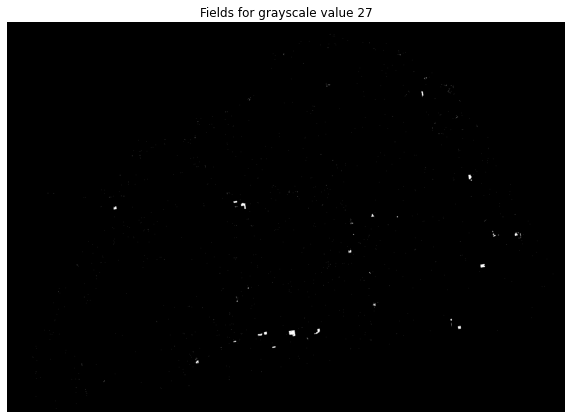

In [32]:
#Show all fields for a specific grayscale value

# Specify the grayscale value you want to display (change it to the value you're interested in)
with rasterio.open(reference_tif_2019) as src:
    ref_image2019 = src.read(1)

test_value = 27  # Replace with your desired grayscale value
print(f"Displaying mask for grayscale value: {test_value}")

# Create a binary mask where all pixels matching the test_value are white (1), others are black (0)
test_mask = (ref_image2019 == test_value)

# Display the mask using matplotlib
plt.figure(figsize=(10, 10))
plt.imshow(test_mask, cmap="gray")
plt.title(f"Fields for grayscale value {test_value}")
plt.axis("off")  # Optional: Hide axis for a cleaner map
plt.show()

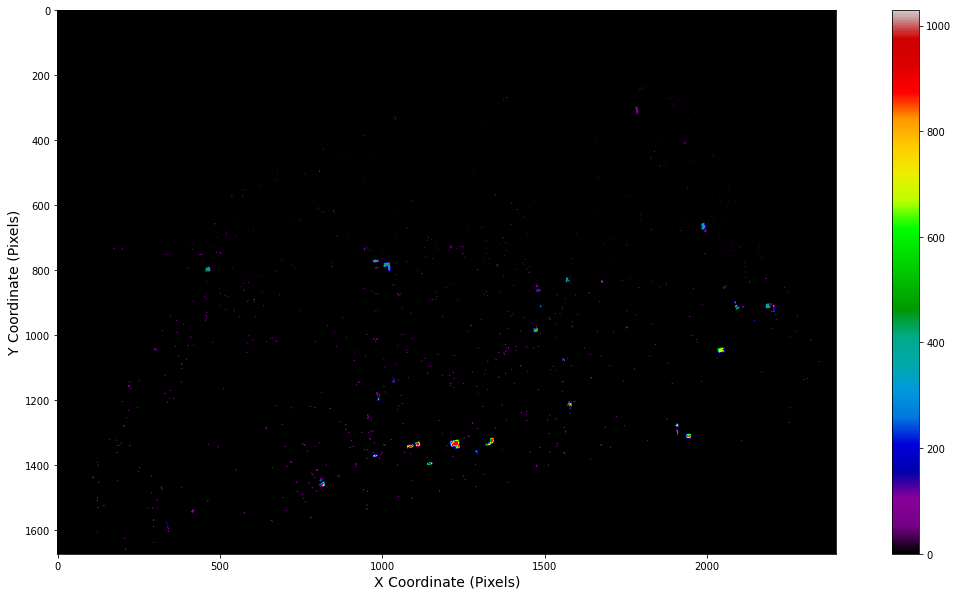

In [33]:
#Show all fields for a specific grayscale value with colored field labels
labeled_test_mask = label(test_mask)
# Display the mask using matplotlib
plt.figure(figsize=(20, 10))
plt.imshow(labeled_test_mask, cmap="nipy_spectral")  # Use a colorful colormap
#plt.title(f"Fields for grayscale value {test_value}")
plt.colorbar()
plt.xlabel("X Coordinate (Pixels)", fontsize=14)
plt.ylabel("Y Coordinate (Pixels)", fontsize=14)
plt.show()

In [40]:
# Get the top 10 field_ids with the most records
top_10_field_ids = field_labels_2019["field_id"].value_counts().head(10)

print("Top 10 field_ids with the most records:")
print(top_10_field_ids)

Top 10 field_ids with the most records:
0       1608690
2552       7101
2288       5847
518        4565
6940       4507
5425       4351
956        3849
689        3844
4461       3713
2406       3573
Name: field_id, dtype: int64


In [8]:
This cell is run to print all unique grayscale values, so we can make sure our crop dictionary is inclusive of everytihng
# Set to store all unique grayscale values across files
all_unique_values = set()

# Loop through the specified TIFF files and prints grayscale values
for tif_path in tif_files:
    with rasterio.open(tif_path) as src:
        band = src.read(1)  # Read the single-band image
        unique_values = np.unique(band)  # Get unique values in this image
        all_unique_values.update(unique_values)  # Add to global set
    
    print(f"Unique grayscale values in {tif_path}: {unique_values}")

Unique grayscale values in 2019_cdl_clipped.tif: [  0   1   4   5  12  13  14  21  24  25  27  28  30  36  37  41  42  43
  44  49  50  53  54  56  57  58  59  61  66  68  70 111 121 122 123 124
 131 141 142 143 152 176 190 195 205 206 219 222 225 229 243]
Unique grayscale values in 2020_cdl_clipped.tif: [  0   1   3   4   5   6  12  13  14  21  22  24  26  27  28  29  30  36
  37  39  41  42  43  44  47  48  49  50  53  54  56  58  59  60  61  66
  68  70  71  76 111 121 122 123 124 131 141 142 143 152 176 190 195 205
 206 222 225 229 242 243 246]
Unique grayscale values in 2021_cdl_clipped.tif: [  0   1   4   5   6  12  13  14  21  24  26  27  28  29  30  31  36  37
  39  41  42  43  44  47  49  50  53  54  56  57  58  59  61  66  68  69
  70  71  76  77  92 111 121 122 123 124 131 141 142 143 152 176 190 195
 205 206 207 216 219 221 222 225 228 229 242 243 245 246]
Unique grayscale values in 2022_cdl_clipped.tif: [  0   1   4   5   6  12  14  21  23  24  26  27  28  29  30  36  37  

In [ ]:
## Step 2 - Model Output Image Processing

In [ ]:
## Step 3 - Create Accuracy Calculator

In [ ]:
## Step 4 - Perform Accuracy Calculation